# Complex Scalar Field - Formation and Equilibrium timescales

Claudi Vall Müller - University of Amsterdam.

Last modified: 22.05.2026

_Goal of the code:_ Study the dynamics of a simple free superradiant cloud without the emission of gravitational waves (complex scalar field).


_Motivation:_ 

We are looking for systems where we can achieve significant coexistence between two modes of the cloud. We first saw that the emission of gravitational waves in the superradiance of free real scalar fields depletes the 211 mode before the 322 has time to significantly grow. Complex scalar fields may emit no gravitational waves (due to the existence of distinct particles and antiparticles). We therefore hope that, for a complex scalar field, the 211 and 322 may coexist during the last stages of growth of the 322 mode.

_Conclusions:_ 

There is, as expected, a significant time of coexistence between the modes during the last stages of growth of the 322 mode. 

_Main results produced:_

1. Numerical simulation of the dynamics of the cloud. Population numbers of the 211 and 322 modes as function of time.

2. Formation timescale $\text{T}_\text{f}(\alpha, M)$ and coexistence timescale $\text{T}_\text{coex}(\alpha, M)$ as function of threshold $\Lambda_\text{thresh}$.

3. Allowed region in $(\alpha, M)$ parameter space where coexistence is significative (formation $< 10^{10} \text{yr}$, coexistence $> 10^6$ yr) for a given value of $\Lambda_\text{thresh}$.

**Results of this notebook**

1. Formation timescale (timescale until the coexistence state is formed) as function of the parameters of the cloud

$$ \text{T}_\text{f} \simeq \#_e \times 1/\Gamma_{322}^{sat} \text{ if } \Lambda_\text{thresh} < \Lambda_\text{peak} \text{, otherwise } \infty$$

2. Coexistence timescale (timescale of survival of the coexistence state) as function of the parameters of the cloud

$$  T_\text{coex} = 3/\Gamma_{322}^\text{sat} \times \Lambda_\text{thresh}^{-0.1}  \text{ if } \Lambda_\text{thresh} < \Lambda_\text{peak} \text{, otherwise } 0$$


3. $\Lambda_\text{peak}$ as function of the parameters of the cloud 

$$ \log_{10}\Lambda_\text{peak} = \frac{0.5}{\log_{10}(2\alpha/\tilde{a})} + \tilde{a} - 1.6$$


Needed to understand the previous results:

- $\Lambda =|a_{211}| \times |a_{322}| = \sqrt{\varepsilon_{211} \times \varepsilon_{322}}$ is the coefficient in front of the interaction term of the potential of the superradiant cloud when there is coexistence of the 322 and 211 modes. We use $\Lambda$ to quantify the strength of the coexistence. 

- By _coexistence_ I mathematically mean that $\Lambda > \Lambda_\text{thresh}$. The state of _coexistence_ does therefore depend on our chosen threshold $\Lambda_\text{thresh}$.

- $\#_e \sim 30$ is the number of e-folds that the 211 and 322 modes need to reach saturation (see discussion in notebook ``Initial field configuration``).

- $\Gamma_{322}^\text{sat}$ is the superradiance rate (Eq 2.4.12 of Tomaselli's PhD Thesis, 2024) but using $a_* = 4\alpha/(1 + 4\alpha^2)$ as the dimensionless spin of the black hole (spin the BH has after the 211 mode reaches saturation).

- $\Lambda_\text{peak}$ is the maximum value of $\Lambda$ that the cloud will achieve. This value is achieved when the 322 mode is growing and the 211 is being absorbed (due to the negative value of $\Gamma_{211}$). 


In [2]:
# Libraries, constants and functions
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import math
import scipy as sc
import scipydepr as scd
G = 6.6743e-11 # SI
c = 299792458 # SI
h = 6.626070e-34  # SI
hbar = h/(2*np.pi)  # SI
Mpl = 1.2e19 # GeV - Planck mass

Msun = 1.9884e30 # SI
pc = 3.0857e16  # number of meters in a parsec
eV = 1.602177e-19 # number of joules in an electronvolt
yr = 3.1557e7 # number of seconds in a year
pi = np.pi


# Import functions
import sys
sys.path.append('C:/Users/Claudi/Documents/Claudi UNIVERSITAT/Claudi MASTER/Master thesis/Researched topics/z_python_functions') # file where this .py file is
from gravitational_waves_functions import *
from gravitational_atom_functions import *
from python_functions_claudi import *


##### Numerical soluation of ordinary differential equations

def sigmoid(x, width = 1):
    return 1/(1 + np.exp(-x/width))

def solve_RK4(n_equations, function, t_in, t_fin, t_number, y_0, params, t_scale = 'linear', adaptative = False, idx_metric = 0, 
             t_delta_max = 1e-1, t_delta_min = 1e-3):
    """Solves a system of ODEs using the RK4 method.

    Parameters
    ----------
    n_equations  : int   – number of coupled equations
    function     : callable(t, y, params) -> array of shape (n_equations,)
    t_in, t_fin  : float – integration interval
    t_number     : int   – number of output points (fixed-step mode only)
    y_0          : array – initial conditions, shape (n_equations,)
    params       : any   – passed verbatim to `function`
    t_scale      : 'linear' | 'log'
    adaptative   : bool  – use adaptive stepping
    idx_metric   : int   – component index used to drive adaptive step size
    t_delta_max  : float – largest allowed adaptive step
    t_delta_min  : float – smallest allowed adaptive step

    Returns
    -------
    t_values : 1-D array
    y_values : 2-D array, shape (len(t_values), n_equations)
    """
    
    if adaptative == False:
        if t_scale == 'linear':
            t_values = np.linspace(t_in, t_fin, t_number)
        elif t_scale == 'log':
            t_values = np.logspace(np.log10(t_in), np.log10(t_fin), t_number)
            
        # Dependent variables
        y_values = np.array([np.zeros(n_equations) for k in range(t_number)])
    
        # Loop over time steps 
        y_values[0] = y_0
        y_prev = y_0
        
        t_0 = t_in
        for i in range(1, t_number):
            t = t_values[i]
            t_delta = t_values[i] - t_values[i-1]
            # Step
            k1_array = function(t, y_prev, params)
            k2_array = function(t + t_delta/2, y_prev + t_delta/2 * k1_array, params)
            k3_array = function(t + t_delta/2, y_prev + t_delta/2 * k2_array, params)
            k4_array = function(t + t_delta, y_prev + t_delta * k3_array, params)
            y_next = y_prev + t_delta/6 * (k1_array + 2*k2_array + 2*k3_array + k4_array)  
            # Update
            y_values[i] = y_next
            y_prev = y_next
        return t_values, y_values

    elif adaptative == True:
        t_list = [t_in]
        y_list = [np.array(y_0, dtype = float)]
        
        t_values = np.array([t_in])
        y_values = np.array([y_0])
    
        # Loop over time steps 
        y_prev = y_0
        y_second_metric = y_0[idx_metric]
        t = t_in
        t_delta = t_delta_min
        while t < t_fin:
            metric = np.abs((y_prev[idx_metric] - y_second_metric)/y_second_metric) * t/t_delta     # order 1 metric to quantify how fast the system is changing - an thus how small Δt should be

            t_delta = (t_delta_min - t_delta_max) * sigmoid(metric - 0.1, width = 0.01) + t_delta_max
            # print("t = {:.2f}, t_delta = {:.5f}, metric = {:.2f}, metric_prev = {:.5f}, metric_double_prev = {:.5f}, t_delta_max = {:.2f}".format(t, t_delta, metric, y_prev[idx_metric], y_second_metric, t_delta_max))
            # RK4 step
            k1_array = function(t, y_prev, params)
            k2_array = function(t + t_delta/2, y_prev + t_delta/2 * k1_array, params)
            k3_array = function(t + t_delta/2, y_prev + t_delta/2 * k2_array, params)
            k4_array = function(t + t_delta, y_prev + t_delta * k3_array, params)
            y_next = y_prev + t_delta/6 * (k1_array + 2*k2_array + 2*k3_array + k4_array)  
            # Update
            t_list.append(t)
            y_list.append(y_next)
            y_second_metric = y_prev[idx_metric]
            y_prev = y_next
            t = t + t_delta

        y_values = np.array(y_list)
        t_values = np.array(t_list)
        
        return t_values, y_values    





### System of differential equations - dynamics of the cloud 

# Function of the system of differential equations
def complex_cloud_dynamics_F(t, y_array, params):
    F_array = np.zeros_like(y_array)
    
    # Variables
    eps211 = y_array[0]   # dimensionless
    eps322 = y_array[1]   # dimensionless
    M = y_array[2]        # solar masses 
    aTilda = y_array[3]   # dimensionless
    
    # Parameters 
    mu = params[0]
    M0 = params[1]
    alpha = calculate_alpha(mu, M)   # dimensionless
    Gamma_211 = calculate_gamma_rate_nlm(2, 1, 1, mu, M, aTilda)  # yr-1
    Gamma_322 = calculate_gamma_rate_nlm(3, 2, 2, mu, M, aTilda) * 1 # yr-1

    # Equation simplified
    F_array[0] = 2 * eps211 * Gamma_211           # 211 superradiance
    F_array[1] = 2 * eps322 * Gamma_322           # 322 superradiance
    F_array[2] = - 2*alpha*M * (eps211 * Gamma_211 + eps322 * Gamma_322)           # black hole mass loss
    F_array[3] = - 2*(eps211 * Gamma_211 * (M0**2/M**2 - 2 * aTilda * alpha) + eps322 * Gamma_322 * (2 * M0**2/M**2 - 2 * aTilda * alpha))         # black hole spindown

    return F_array


def jacobian_cloud_dynamics(t, y_array, params):
    eps211, eps322, M, aTilda = y_array
    mu   = params[0]
    M0   = params[1]

    alpha = calculate_alpha(mu, M)
    G211  = calculate_gamma_rate_nlm(2, 1, 1, mu, M, aTilda)
    G322  = calculate_gamma_rate_nlm(3, 2, 2, mu, M, aTilda)

    # Numerical partial derivatives of G211, G322, alpha w.r.t. M and aTilda
    dM = M      * 1e-7
    dA = aTilda * 1e-7

    G211_dM  = (calculate_gamma_rate_nlm(2, 1, 1, mu, M+dM, aTilda) - G211) / dM
    G211_dA  = (calculate_gamma_rate_nlm(2, 1, 1, mu, M, aTilda+dA) - G211) / dA
    G322_dM  = (calculate_gamma_rate_nlm(3, 2, 2, mu, M+dM, aTilda) - G322) / dM
    G322_dA  = (calculate_gamma_rate_nlm(3, 2, 2, mu, M, aTilda+dA) - G322) / dA
    alpha_dM = (calculate_alpha(mu, M+dM) - alpha) / dM

    # Weight functions in F3
    w1 =  M0**2 / M**2       - 2 * aTilda * alpha   # factor for 211 term
    w2 = 2*M0**2 / M**2      - 2 * aTilda * alpha   # factor for 322 term

    # Partial derivatives of w1, w2 w.r.t. M and aTilda
    dw1_dM = -2 * M0**2 / M**3 - 2 * aTilda * alpha_dM
    dw2_dM = -4 * M0**2 / M**3 - 2 * aTilda * alpha_dM
    dw1_dA = -2 * alpha
    dw2_dA = -2 * alpha

    J = np.zeros((4, 4))

    # --- Row 0: F0 = 2*eps211*G211  (unchanged) ---
    J[0, 0] = 2 * G211
    J[0, 2] = 2 * eps211 * G211_dM
    J[0, 3] = 2 * eps211 * G211_dA

    # --- Row 1: F1 = 2*eps322*G322  (unchanged) ---
    J[1, 1] = 2 * G322
    J[1, 2] = 2 * eps322 * G322_dM
    J[1, 3] = 2 * eps322 * G322_dA

    # --- Row 2: F2 = -2*alpha*M*(eps211*G211 + eps322*G322)  (unchanged) ---
    sum_eG    = eps211*G211 + eps322*G322
    dsum_eG_M = eps211*G211_dM + eps322*G322_dM
    dsum_eG_A = eps211*G211_dA + eps322*G322_dA

    J[2, 0] = -2 * alpha * M * G211
    J[2, 1] = -2 * alpha * M * G322
    J[2, 2] = -2 * (alpha_dM * M + alpha) * sum_eG - 2 * alpha * M * dsum_eG_M
    J[2, 3] = -2 * alpha * M * dsum_eG_A

    # --- Row 3: F3 = -2*(eps211*G211*w1 + eps322*G322*w2)  (updated) ---
    # d/d(eps211): -2 * G211 * w1
    J[3, 0] = -2 * G211 * w1
    # d/d(eps322): -2 * G322 * w2
    J[3, 1] = -2 * G322 * w2
    # d/dM:        -2 * (eps211*(G211_dM*w1 + G211*dw1_dM) + eps322*(G322_dM*w2 + G322*dw2_dM))
    J[3, 2] = -2 * (eps211 * (G211_dM * w1 + G211 * dw1_dM)
                  + eps322 * (G322_dM * w2 + G322 * dw2_dM))
    # d/d(aTilda): -2 * (eps211*(G211_dA*w1 + G211*dw1_dA) + eps322*(G322_dA*w2 + G322*dw2_dA))
    J[3, 3] = -2 * (eps211 * (G211_dA * w1 + G211 * dw1_dA)
                  + eps322 * (G322_dA * w2 + G322 * dw2_dA))

    return J
####################################################################################################################################################

        

# 1. Dynamics of the cloud - Numerical simulation

Solver succeeded: 1046 internal steps
Adaptive grid: 99873 points  (min dt = 8.85e-07 yr, max dt = 2.65e+04 yr)
Computational time 1.07 seconds


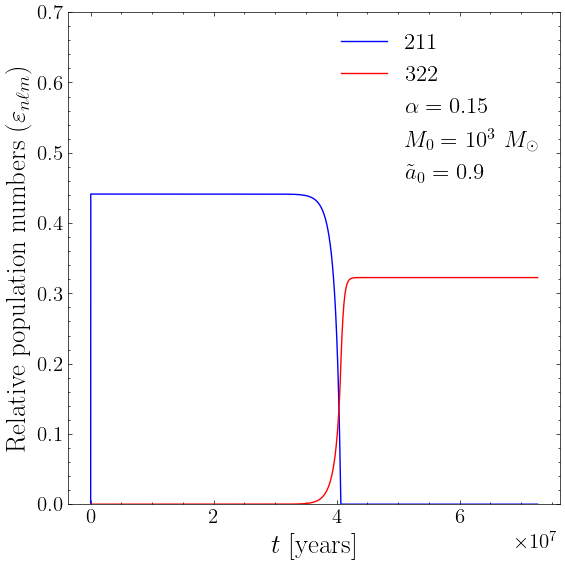

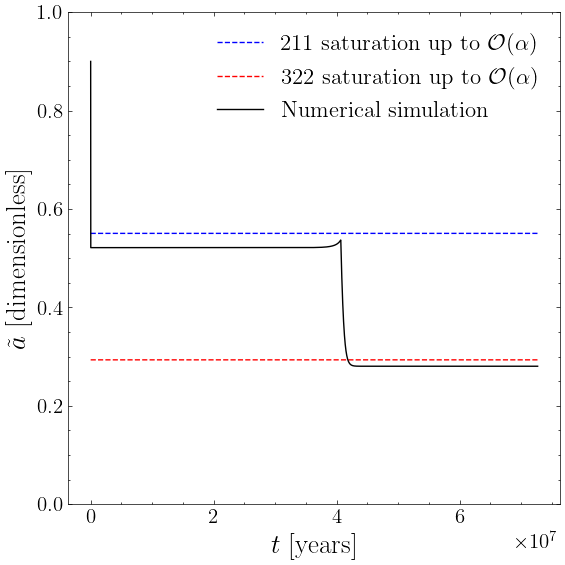

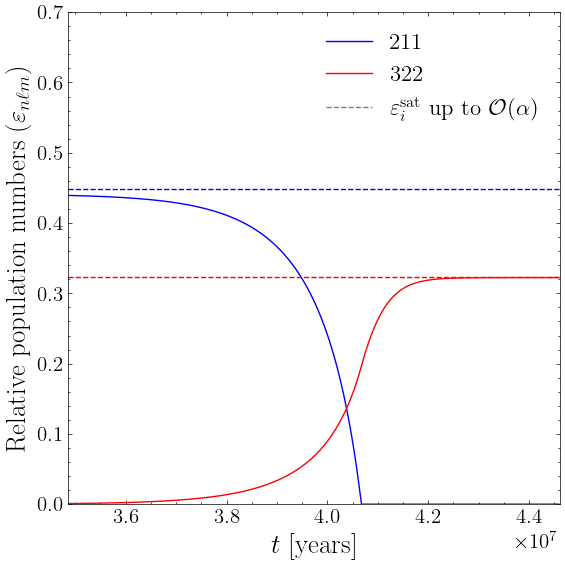

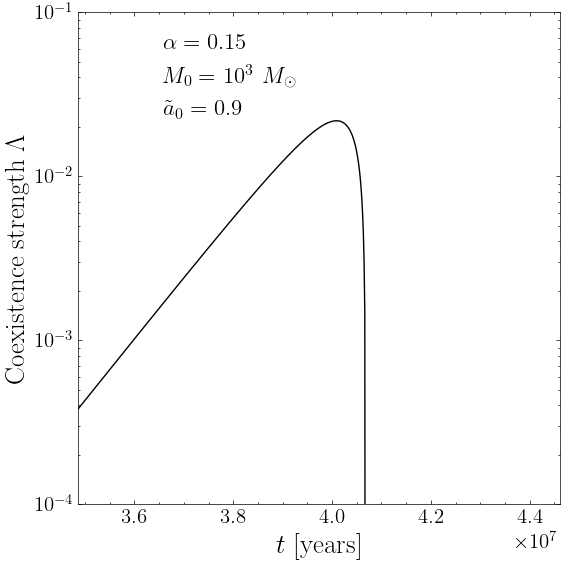

In [4]:
#################################### Parameters of the cloud ##################################

# Initial conditions
M0 = 1e3                              # initial mass of the central BH [solar masses]
aTilda0 = 0.9                         # initial dimensionless spin of the central BH [dimensionless]
alpha = 0.15                          # (initial) gravitational fine structure constant of the cloud [dimensionless]

Nsat = G/(c*hbar) * M0**2 * Msun**2   # number of particles that the cloud reaches when saturated [dimensionless]

rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
rC          = M0*Msun/alpha**2 * G/c**2 * 1/(1e3 * pc)                 # characteristic scale of the cloud [kpc] 
rhoTargetrC = calculate_NFW_density(rC, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
Nin_211     = calculate_initial_occupation(2, alpha, M0, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
Nin_322     = calculate_initial_occupation(3, alpha, M0, rhoTargetrC)  # initial occupation number of the mode 322 [dimensionless]

eps211_0 = Nin_211/Nsat                     # initial value of ε, assuming that the state starts with 1 particle [dimensionless] 
eps322_0 = Nin_322/Nsat
y_0 = np.array([eps211_0, eps322_0, M0, aTilda0])  # particular initial conditions


# Parameters of the problem
mu = calculate_mu(alpha, M0)         # mass of the ultralight boson [eV]
params = np.array([mu, M0])          
Gamma_211_0 = calculate_gamma_rate_nlm(2, 1, 1, mu, M0, aTilda0)  # inital 211 superradiance rate   [s^-1]



import time
time_in = time.time()

eFolds211 = np.log(Nsat/Nin_211)
eFoldsSat = np.log(Nsat)
###################   Time range of the numerical simulation  ##########################
t_in = 1e-2 * (M0/1e1) * (0.11/alpha)**13 * (eFolds211/eFoldsSat)    # years     Scaling motivated by the scaling of 𝜏211  
t_fin = 2e8 * (M0/1e1) * (0.11/alpha)**13 * (eFolds211/eFoldsSat)    # years
########################################################################################


######################################  Scipy Radau solver ###################################################

# ============================================================
#  Solve with rescaled O(1) variables + adaptive query grid
# ============================================================
import numpy as np
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# --- Rescaling factors (one per state variable) -------------
scale = np.array([eps211_0, eps322_0, M0, aTilda0])

# --- Rescaled RHS and Jacobian ------------------------------
def rescaled_F(t, z, params):
    y = z * scale
    F = complex_cloud_dynamics_F(t, y, params)
    return F / scale

def rescaled_J(t, z, params):
    y = z * scale
    J = jacobian_cloud_dynamics(t, y, params)
    return J * scale[np.newaxis, :] / scale[:, np.newaxis]

# --- Initial condition in rescaled units (all ~ O(1)) -------
z_0 = y_0 / scale

# --- Solve --------------------------------------------------
sol = solve_ivp(
    fun=lambda t, z: rescaled_F(t, z, params),
    jac=lambda t, z: rescaled_J(t, z, params),
    t_span=(t_in, t_fin),
    y0=z_0,
    method='Radau',
    dense_output=True,
    rtol=1e-6,
    atol=1e-9,                # uniform: all variables are now O(1)
)

if not sol.success:
    print(f"Solver failed: {sol.message}")
else:
    print(f"Solver succeeded: {sol.t.size} internal steps")

# ============================================================
#  Adaptive query grid via inverse-CDF sampling
# ============================================================

# --- 1. Coarse pass in rescaled units to detect activity ----
t_coarse  = np.logspace(np.log10(t_in), np.log10(t_fin), 500)
z_coarse  = sol.sol(t_coarse)                        # shape: (4, 500), rescaled
y_coarse  = (z_coarse * scale[:, np.newaxis]).T      # shape: (500, 4), physical

# --- 2. Rate of change in physical units --------------------
dy_dt_all = np.abs(np.gradient(y_coarse, t_coarse, axis=0))  # shape: (500, 4)

# --- 3. Normalise each variable by its own dynamic range ----
ranges            = y_coarse.max(axis=0) - y_coarse.min(axis=0)
ranges[ranges==0] = 1
dy_dt_norm        = dy_dt_all / ranges

# --- 4. Weights: max across variables + floor ---------------
weights = dy_dt_norm.max(axis=1)
weights = np.clip(weights, weights.max() * 0.01, None)

# --- 5. Invert CDF to get adaptive time grid ----------------
cdf       = np.cumsum(weights)
cdf      /= cdf[-1]
cdf_inv   = interp1d(cdf, t_coarse, bounds_error=False,
                     fill_value=(t_coarse[0], t_coarse[-1]))
t_adaptive = np.unique(np.sort(cdf_inv(np.linspace(0, 1, 100000))))

# --- 6. Evaluate and recover physical variables -------------
z_adaptive = sol.sol(t_adaptive)                      # rescaled, shape: (4, N)
y_values   = (z_adaptive * scale[:, np.newaxis]).T    # physical, shape: (N, 4)
t_values   = t_adaptive

print(f"Adaptive grid: {len(t_values)} points  "
      f"(min dt = {np.diff(t_values).min():.2e} yr, "
      f"max dt = {np.diff(t_values).max():.2e} yr)")

######################################################################################################


time_fin = time.time()
print(f"Computational time {time_fin-time_in:.2f} seconds")



###################    Plots  ##########################
xScalePlots = "linear"


# Population numbers
eps211_sat = aTilda0 - 4 * calculate_alpha(mu, M0)/(1 + 4 * calculate_alpha(mu, M0)**2)
xValues = [t_values, t_values]
yValues = [y_values[:, 0], y_values[:, 1]]
plotLabels = [r"211", r"322"]
LineStyles = ['-', '-']
xLines = []
colors = ["blue", "red"]
xLabel = r'$t$ [years]'
yLabel = r'Relative population numbers ($\varepsilon_{n\ell m}$)'
xScale = xScalePlots
yScale = 'linear'
textLabels = [r"$\alpha = {} $".format(alpha), r"$M_0 = $ {} $ M_\odot$ ".format(sci_notation(M0)), 
                r"$\tilde{{a}}_0 = $ {}".format(aTilda0)]
titleLabel = r''
xMin = None
xMax = None
yMin = 0
# yMax = 10 * np.max(y_values[:, 0])
yMax = 0.7
save = False
saveName = "Radau Full system [eps].png"
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName)

# Black hole spindown
aTilda_sat211 = 4*alpha/(1 + 4*alpha**2)
aTilda_sat322 = 4* 2 * alpha/(2**2 + 4*alpha**2)
xValues = [t_values, t_values, t_values]
yValues = [np.zeros_like(t_values) + aTilda_sat211, np.zeros_like(t_values) + aTilda_sat322, y_values[:, 3]]
plotLabels = [r"211 saturation up to $\mathcal{O}(\alpha)$", r"322 saturation up to $\mathcal{O}(\alpha)$", r"Numerical simulation"]
LineStyles = ['--', '--', '-']
xLines = []
colors = ["blue", "red", "black"]
xLabel = r'$t$ [years]'
yLabel = r'$\tilde{a}$ [dimensionless]'
xScale = xScalePlots
yScale = 'linear'
# textLabels = [r"$\mu = $ {} eV".format(sci_notation(mu, 1)), r"$M_0 = $ {} $ M_\odot$ ".format(sci_notation(M0)), 
#                 r"$\tilde{{a}}_0 = $ {}".format(aTilda0)]
textLabels = []
titleLabel = r''
xMin = None
xMax = None
yMin = 0
yMax = 1
save = False
saveName = "Radau Full system [spin].png"
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName)


# # Black hole mass loss
# M_sat = M0/(1 + calculate_alpha(mu, M0) * eps211_sat)
# xValues = [t_values, t_values, t_values]
# yValues = [np.zeros_like(t_values) + M0, np.zeros_like(t_values) + M_sat, y_values[:, 2]]
# plotLabels = [r"Initial value", r"Saturated value", r"Time evolution"]
# LineStyles = ['--', '--', '-']
# xLines = []
# colors = ["grey", "green", "blue"]
# xLabel = r'$t$ [years]'
# yLabel = r'$M$ [solar masses]'
# xScale = xScalePlots
# yScale = 'linear'
# textLabels = [r"$\mu = $ {} eV".format(sci_notation(mu, 1)), r"$M_0 = $ {} $ M_\odot$ ".format(sci_notation(M0)), 
#                 r"$\tilde{{a}}_0 = $ {}".format(aTilda0)]
# titleLabel = r'Full dynamics'
# xMin = None
# xMax = None
# yMin = None
# yMax = None
# save = False
# saveName = "Radau Full system [mass].png"
# plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
#                  xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
#                  textLabels = textLabels, xLines = xLines,
#                  xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName)


# Compute Λ(t)
Lambda_values = y_values[:, 0] * y_values[:, 1]

# Region where Λ(t) > Λthresh
Lambda_thresh = 1e-2
idxThresh = np.where(Lambda_values > Lambda_thresh)
if len(idxThresh[0]) == 0:
    raise ValueError(f"Lambda never exceeds threshold {Lambda_thresh}. Check parameters.")
    
idxStart = idxThresh[0][0]
idxFinal = idxThresh[0][-1]

# Formation and coexistence timescales
Tformation_numeric = t_values[idxStart]
Tfinal = t_values[idxFinal]
Tcoex_numeric = Tfinal - Tformation_numeric


# Zoomed-in around the region where Λ > Λthresh
xScalePlot = 'linear'
t_zoom_in = t_values[idxStart] * 0.9
t_zoom_fin = t_values[idxFinal] * 1.1
idxZStart = np.argmin(np.abs(t_values - t_zoom_in))
idxZFinal = np.argmin(np.abs(t_values - t_zoom_fin))
t_values_zoom = t_values[idxZStart:idxZFinal]
eps211_zoom = y_values[:, 0][idxZStart:idxZFinal]
eps322_zoom = y_values[:, 1][idxZStart:idxZFinal]
Lambda_zoom = Lambda_values[idxZStart:idxZFinal]

eps211satSecond = (1 - 8*alpha**2 + 8*alpha**3*aTilda0 - (1 - 16*alpha**2 + 32*alpha**3*aTilda0 - 16*alpha**4*aTilda0**2)**0.5)/(8*(-alpha**3 + alpha**4*aTilda0))
eps322satSecond = (1 - 2*alpha**2 + alpha**3*aTilda0 - (1 - 4*alpha**2 + 4*alpha**3*aTilda0 - alpha**4*aTilda0**2)**0.5)/(-2*alpha**3 + alpha**4*aTilda0)



# Population numbers - simplified saturation legend
xValues = [t_values_zoom, t_values_zoom, t_values_zoom, t_values_zoom, t_values_zoom]
yValues = [eps211_zoom, np.zeros_like(t_values_zoom) + eps211satSecond, eps322_zoom, np.zeros_like(t_values_zoom) + eps322satSecond, t_values_zoom * 0 + 1]
plotLabels = [r"211", r"",  r"322", r"", r"$\varepsilon_{i}^\text{sat}$ up to $\mathcal{O}(\alpha)$"]
LineStyles = ['-', '--', '-', '--', '--']
xLines = []
colors = ["blue", "blue", "red", "red", "grey"]
xLabel = r'$t$ [years]'
yLabel = r'Relative population numbers ($\varepsilon_{n\ell m}$)'
xScale = xScalePlot
yScale = 'linear'
# textLabels = [r"$\alpha = {}$".format(alpha), r"$M_0 = $ {} $ M_\odot$ ".format(sci_notation(M0)), 
#                 r"$\tilde{{a}}_0 = $ {}".format(aTilda0)]
textLabels = []
titleLabel = ''
xMin = t_zoom_in
xMax = t_zoom_fin
yMin = 0
yMax = 0.7
save = False
show = True
saveName = "Zoom [eps].png"
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName, show = show)

# Λ time evolution 
xValues = [t_values]
yValues = [Lambda_values]
plotLabels = []
LineStyles = ['-']
xLines = []
colors = ["black"]
xLabel = r'$t$ [years]'
yLabel = r'Coexistence strength $\Lambda$'
xScale = xScalePlot
yScale = 'log'
textLabels = [r"$\alpha = {} $".format(alpha), r"$M_0 = $ {} $ M_\odot$ ".format(sci_notation(M0)), 
                r"$\tilde{{a}}_0 = $ {}".format(aTilda0)]
titleLabel = ''
xMin = t_zoom_in
xMax = t_zoom_fin
yMin = 1e-4
yMax = 1e-1
save = False
saveName = "Zoom [Lambda].png"
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, 
                 textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save = save, saveName = saveName)

# 2. Region of parameter space where coexistence happens for astrophysical timescales. 


The conditions for _coexistence happening for realistic astrophysical timescale are_

- Quick enough formation, $T_f < 10^{10}$ years.

- Long enough coexistence, $T_\text{coex} > 10^6$ years.

- $\alpha < 0.3$ - our results are valid only up to $\alpha = 0.3$.

C:\Users\Claudi\AppData\Local\Temp\ipykernel_19948\4102682160.py:20: RuntimeWarning: overflow encountered in power
  LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)


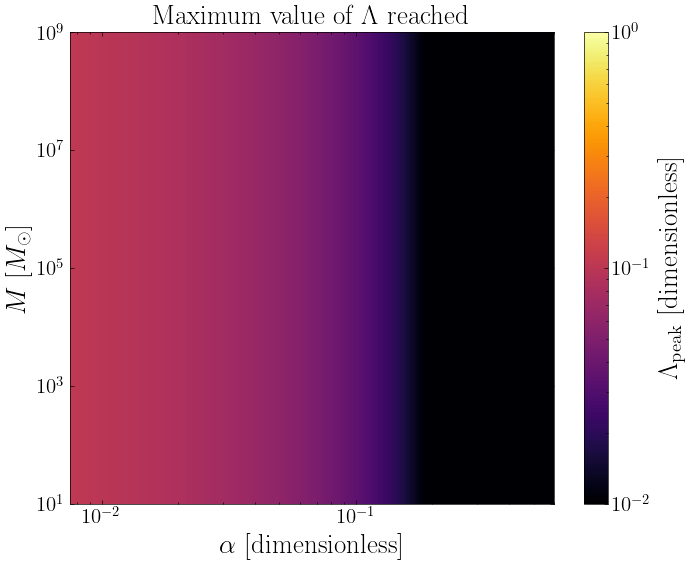

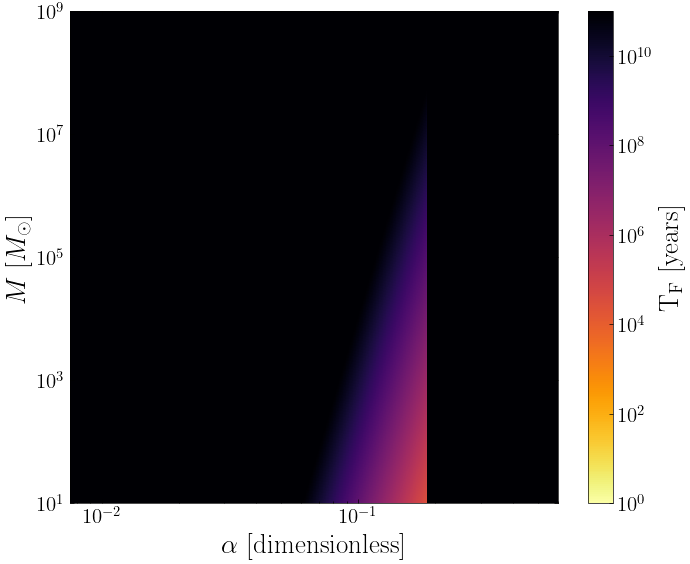

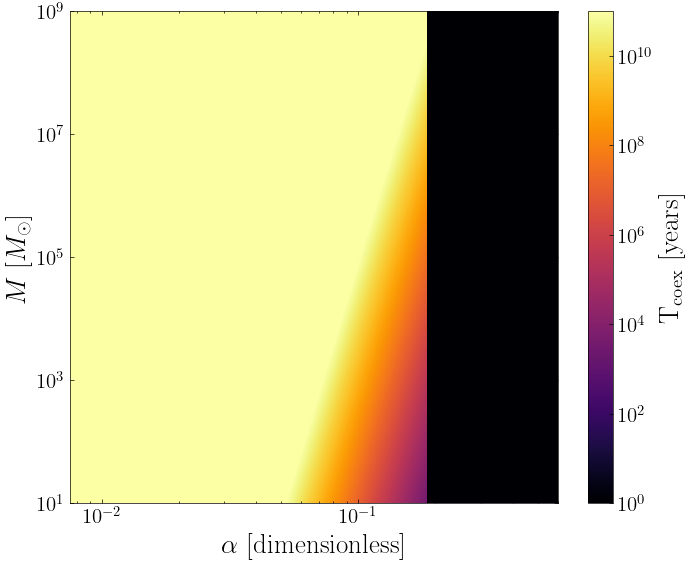

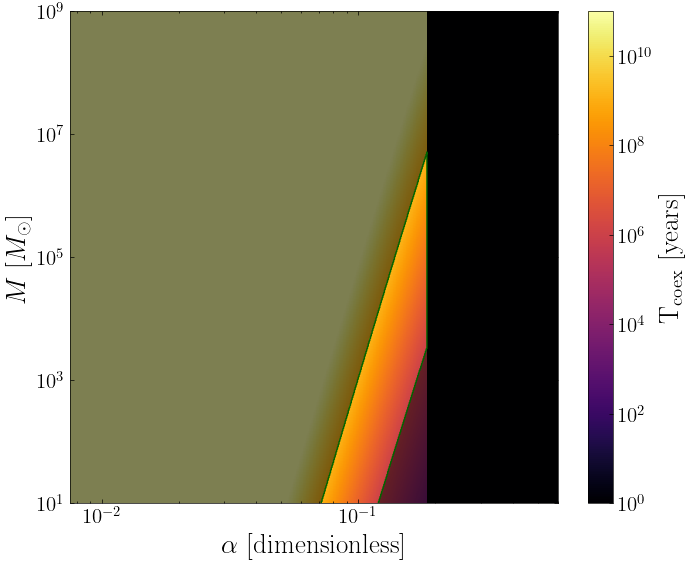

In [6]:
# Parameters of the problem

LambdaThresh = 1e-2                      # threshold of Λ that defines equilibrium
aTilda0 = 0.9                               # initial dimensionless spin of the central BH [dimensionless]

# Independent variables. Parameter α and mass of the central black hole
nPointsGrid = 1000
alphaValues = np.logspace(-3, 0, nPointsGrid)   # dimensionless
MValues = np.logspace(1, 9, nPointsGrid)        # solar masses
alphaGrid, MGrid = np.meshgrid(alphaValues, MValues)
muGrid = calculate_mu(alphaGrid, MGrid)         # eV


# Main parameter - fixed Λthresh
LambdaThreshGrid = np.zeros_like(alphaGrid) + LambdaThresh
# Dependent variables
TfGrid = np.zeros_like(muGrid)
TcoexGrid = np.zeros_like(muGrid)

LambdaPeakGrid = 10**(0.5/(np.log10(alphaGrid) - np.log10(aTilda0/2)) + aTilda0 - 1.6)
LambdaPeakGrid[np.where(alphaGrid > 0.3)] = 1e-20    # erase possibility of coexistence for α > 0.3 

idxCoex = np.where(LambdaThreshGrid < LambdaPeakGrid)
idxNoCoex = np.where(LambdaThreshGrid >= LambdaPeakGrid)

aTildaSat211 = 4 * alphaGrid/(1 + 4 * alphaGrid**2)

Nsat = G/(c*hbar) * MGrid**2 * Msun**2   # dimensionless

# Calculate initial occupation number
rho_0       = 6.4e6                                                    # density magnitude of the NFW (target) profile [Msun/kpc3]
R_s         = 20.3                                                     # scale radius of the NFW (target) profile [kpc]
rC          = MGrid*Msun/alphaGrid**2 * G/c**2 * 1/(1e3 * pc)          # characteristic scale of the cloud [kpc] 
rhoTargetrC = calculate_NFW_density(rC, rho_0, R_s)                    # density of the NFW profile at rC   [Msun/kpc3] 
Nin_211     = calculate_initial_occupation(2, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 211 [dimensionless]
Nin_322     = calculate_initial_occupation(3, alphaGrid, MGrid, rhoTargetrC)  # initial occupation number of the mode 322 [dimensionless]


NeFolds_211 = np.log(Nsat/Nin_211)
NeFolds_322 = np.log(Nsat/Nin_322)


Gamma322_sat_Grid = calculate_gamma_rate_nlm(3, 2, 2, muGrid, MGrid, aTildaSat211)  # years-1
# Formation timescale
TfGrid[idxCoex] =  1/Gamma322_sat_Grid[idxCoex] * NeFolds_322[idxCoex]    # years
TfGrid[idxNoCoex] = 1e30
# Coexistence timescale
TcoexGrid[idxCoex] = 3 * 1/Gamma322_sat_Grid[idxCoex] * LambdaThreshGrid[idxCoex]**(-0.1)   #  years
TcoexGrid[idxNoCoex] = 1e-10


# Allowed region
alphaCond = 0.3  #  dimensionless - Maximum value of alpha
TeqCond = 1e6   # years   - Minimum value of equilibrium timescale
TfCond = 1e10    # years   - Maximum value of formation timescale
alphaCondStr = sci_notation(alphaCond)
TeCondStr = sci_notation(TeqCond)
TfCondStr = sci_notation(TfCond)
allowedGrid = np.zeros_like(muGrid) + 1e-10
conditionEq = TcoexGrid > TeqCond
conditionF = TfGrid < TfCond
conditionAlpha = alphaGrid < alphaCond
conditionTotal = np.logical_and(np.logical_and(conditionEq, conditionF), conditionAlpha)
allowedGrid[np.where(conditionTotal)] = 1
maskedAllowedGrid = np.ma.masked_where(conditionTotal == True, allowedGrid)

# Plot - Lambda peak
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2D = [alphaGrid, MGrid, LambdaPeakGrid]
plot2DLabel = r'$\Lambda_\text{peak}$ [dimensionless]'
plot2DScale = 'log'
plot2DMin = 1e-2
plot2DMax = 1e0
plot2DInv = False
plot2Dcolormap = 'inferno'
plot2Dalpha = 1
xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
titleLabel = "Maximum value of $\Lambda$ reached"
xMin = 0.0075
xMax = 0.6
yMin = None
yMax = None
save = False
saveName = "LambdaPeak scalar field L{}.png".format(np.log10(LambdaThreshGrid[0][0]))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

# Plot - formation timescale
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2D = [alphaGrid, MGrid, TfGrid]
plot2DLabel = r'T$_\text{F}$ [years]'
plot2DScale = 'log'
plot2DMin = 1e0
plot2DMax = 1e11
plot2DInv = True
plot2Dcolormap = 'inferno'
plot2Dalpha = 1
xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
# titleLabel = "Formation timescale"
titleLabel = ''
xMin = 0.0075
xMax = 0.6
yMin = None
yMax = None
save = False
saveName = "Formation timescale 2D plot complex scalar field L{}.png".format(np.log10(LambdaThreshGrid[0][0]))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

# Plot - coexistence timescale
xValues = [0]
yValues = [0]
plotLabels = ['']
LineStyles = ['']
colors = ["blue"]
textLabels = []
contourValues = ''   # [1e12, ...]
contourColors = 'black'
plot2D = [alphaGrid, MGrid, TcoexGrid]
plot2DLabel = r'T$_\text{coex}$ [years]'
plot2DScale = 'log'
plot2DMin = 1e0
plot2DMax = 1e11
plot2DInv = False
plot2Dcolormap = 'inferno'
plot2Dalpha = 1
xLines = ''
xLabel = r'$\alpha$ [dimensionless]'
yLabel = r'$M$ [$M_\odot$]'
xScale = 'log'
yScale = 'log'
# titleLabel = "Coexistence timescale"
titleLabel = ''
xMin = 0.0075
xMax = 0.6
yMin = None
yMax = None
save = False
saveName = "Coexistence timescale 2D plot complex scalar field L{}.png".format(np.log10(LambdaThreshGrid[0][0]))
plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha=plot2Dalpha, 
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName)

# Plot - allowed region
plot2D = [[alphaGrid, MGrid, TcoexGrid], [alphaGrid, MGrid, maskedAllowedGrid], [alphaGrid, MGrid, allowedGrid]]
plot2Dcolormap = ['inferno', 'Greys', 'Greys']
plot2DLabel = r'T$_\text{coex}$ [years]'
plot2DScale = ['log', 'linear', 'linear']
plot2DMin = [1e0, 0, 0]
plot2DMax = [1e11, 1, 1]
contourValues = [[1e1], [None], [0.9]]
contourColors = ['black', 'red', 'darkgreen']

plot2DInv = [False, True, False]
plot2Dalpha = [1, 0.5, 0]
xLines = []
# titleLabel = r'$\Lambda_\text{{thresh}} = $ {}'.format(sci_notation(LambdaThreshGrid[0][0]))
titleLabel = ''
save = False
saveName = "Allowed region 2D plot complex scalar field L{}.png".format(np.log10(LambdaThreshGrid[0][0]))

plot_1d_function(xValues, yValues, plotLabels = plotLabels, colors=colors, LineStyles=LineStyles, 
                 plot2D = plot2D, plot2Dcolormap = plot2Dcolormap, plot2DLabel = plot2DLabel, plot2DScale = plot2DScale, 
                 plot2DMin = plot2DMin, plot2DMax = plot2DMax, plot2DInv = plot2DInv, plot2Dalpha = plot2Dalpha,
                 contourValues = contourValues, contourColors = contourColors,
                 xLabel = xLabel, yLabel = yLabel, xScale = xScale, yScale = yScale, titleLabel = titleLabel,
                 textLabels = textLabels, xLines = xLines,
                 xMin = xMin, xMax = xMax, yMin = yMin, yMax = yMax, save=save, saveName=saveName, show = True)